In [2]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from copy import deepcopy


from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, classification_report
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Removed SMOTE import
from scipy import stats  # For statistical tests
from scipy.stats import f_oneway




import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Input, MultiHeadAttention,GlobalMaxPooling1D,BatchNormalization,Bidirectional,Lambda,Attention,Concatenate
from tensorflow.keras.layers import LayerNormalization, GlobalAveragePooling1D, Embedding
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from collections import Counter

import pickle

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Collecting Training and Testing Dataset File Paths
dfps2019_train = []
dfps2019_test = []
labels = set()


for dirname, _, filenames in os.walk(r'E:\DACS\DACS\Data\CICDDoS2019'):

    for filename in filenames:
        if filename.endswith('-training.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_train.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)
        elif filename.endswith('-testing.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_test.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)

print("Các nhãn (label) tìm thấy trong CICDDos2019:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2019\DNS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Portmap-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\SNMP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\TFTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-training.parquet
Các nhãn (label) tìm thấy trong CICDDos2019:
- DNS
- LDAP
- MSSQL
- NTP
- NetBIOS
- Portmap
- SNMP
- Syn
- TFTP
- UDP

In [6]:
data_dir = r'E:\DACS\DACS\Data\CICDDoS2017'
labels = set()

dfps2017_train = [] 
for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.parquet'):
            file_path = os.path.join(dirname, filename)
            dfps2017_train.append(file_path)
            label = filename.split('-')[0]
            labels.add(label)
            print(file_path)
print("Các nhãn (label) tìm thấy trong CICDDos2017:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2017\Benign-Monday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Botnet-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Bruteforce-Tuesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DDoS-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DoS-Wednesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Infiltration-Thursday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Portscan-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\WebAttacks-Thursday-no-metadata.parquet
Các nhãn (label) tìm thấy trong CICDDos2017:
- Benign
- Botnet
- Bruteforce
- DDoS
- DoS
- Infiltration
- Portscan
- WebAttacks


In [7]:
df_2017 = pd.concat([pd.read_parquet(dfp) for dfp in dfps2017_train], ignore_index=True)
df_2019train = pd.concat([pd.read_parquet(dfp) for dfp in dfps2019_train], ignore_index=True)
df_2019test = pd.concat([pd.read_parquet(dfp) for dfp in dfps2019_test], ignore_index=True)

df_2019_all = pd.concat([df_2019train, df_2019test], ignore_index=True)

In [8]:
print("Tổng số mẫu CICDDos2017:", len(df_2017))
print("Tổng số mẫu CICDDoS2019 train:", len(df_2019train))
print("Tổng số mẫu CICDDoS2019 test:", len(df_2019test))


print("Tổng số mẫu CICDDoS2019 (gộp train + test):", len(df_2019_all))


Tổng số mẫu CICDDos2017: 2313810
Tổng số mẫu CICDDoS2019 train: 125170
Tổng số mẫu CICDDoS2019 test: 306201
Tổng số mẫu CICDDoS2019 (gộp train + test): 431371


In [9]:
df_2017 = df_2017[df_2017['AttackType'].isin(['Benign', 'DDoS'])]
print(df_2017['AttackType'].value_counts())


print("2019 train:", df_2019train['AttackType'].value_counts())
print("2019 test:", df_2019test['AttackType'].value_counts())


KeyError: 'AttackType'

In [ ]:
df_2017 = df_2017[df_2017['binary_label'].isin(['Benign', 'DDoS'])]


df_2019train = df_2019train[df_2019train['binary_label'].isin(['Benign', 'DDoS'])]
df_2019test = df_2019test[df_2019test['binary_label'].isin(['Benign', 'DDoS'])]


NameError: name 'df_2017' is not defined

In [ ]:
df_2017['is_ddos'] = df_2017['binary_label'].map({'Benign': 0, 'DDoS': 1})


df_2019train['is_ddos'] = df_2019train['binary_label'].map({'Benign': 0, 'DDoS': 1})
df_2019test['is_ddos'] = df_2019test['binary_label'].map({'Benign': 0, 'DDoS': 1})

In [ ]:
features = [col for col in df_2017.columns if col not in ['Label', 'AttackType', 'binary_label', 'is_ddos']]
import numpy as np
features = [col for col in features if np.issubdtype(df_2017[col].dtype, np.number)]


In [ ]:
# Gộp dữ liệu lại
df_train_all = pd.concat([df_2017, df_2019train], ignore_index=True)

# Xáo trộn dữ liệu train
df_train_all = df_train_all.sample(frac=1, random_state=42).reset_index(drop=True)

# Lấy features
X_train_all = df_train_all[features].values
y_train_all = df_train_all['is_ddos'].values

# Chuẩn hóa với MinMaxScaler (fit trên train_all, transform trên cả train_all và test)
scaler = MinMaxScaler()
X_train_all = scaler.fit_transform(X_train_all)
X_test = scaler.transform(df_2019test[features].values)
y_test = df_2019test['is_ddos'].values

In [ ]:
# Chỉ 2019 

scaler = MinMaxScaler()
X_train_2019 = scaler.fit_transform(df_2019train[features])
X_test_2019 = scaler.transform(df_2019test[features])

y_train_2019 = df_2019train['is_ddos'].values
y_test_2019 = df_2019test['is_ddos'].values



In [ ]:
# Fit scaler trên tập train (vd: train là 2017, test là 2019)
scaler = MinMaxScaler()
X_train_2017 = scaler.fit_transform(df_2017[features].values) 
X_test = scaler.transform(df_2019test[features].values)

y_train = df_2017['is_ddos'].values
y_test = df_2019test['is_ddos'].values

In [ ]:

X_train_model = X_train_all.reshape(-1, X_train_all.shape[1], 1)
X_test_model = X_test.reshape(-1, X_test.shape[1], 1)

y_train_model = y_train_all
y_train_bin_cat = to_categorical(y_train_model, num_classes=2)

y_test_bin_cat = to_categorical(y_test, num_classes=2)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train_model), y=y_train_model)
class_weight_dict = dict(zip(np.unique(y_train_model), class_weights))
print("Class weights:", class_weight_dict)


Class weights: {np.int64(0): np.float64(0.5510827698153671), np.int64(1): np.float64(5.3940180985407995)}


In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6, 
    verbose=1
)

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical

# Reshape lại X_train_model để oversample (phải là 2D)
X_train_flat = X_train_model.reshape(X_train_model.shape[0], -1)

# Oversample cho cân bằng 2 lớp
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_flat, y_train_model)

# Đưa về lại shape 3D cho mô hình
X_resampled = X_resampled.reshape(-1, X_train_model.shape[1], X_train_model.shape[2])
y_resampled_cat = to_categorical(y_resampled, num_classes=2)


In [ ]:

print("Train shape:", X_train_model.shape, y_train_bin_cat.shape)
print("Test shape:", X_test_model.shape, y_test.shape)
print("Unique train labels:", np.unique(np.argmax(y_train_bin_cat, axis=1), return_counts=True))
print("Unique test labels:", np.unique(y_test, return_counts=True))
print("Any NaN in train:", np.isnan(X_train_model).any())
print("Any NaN in test:", np.isnan(X_test_model).any())

def create_binary_cnn(input_shape):
    model = Sequential([
        Conv1D(128, kernel_size=5, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.35),
        Conv1D(48, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dense(48, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.25),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0007), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_binary_cnn(X_resampled.shape[1:])
history = cnn_model.fit(
    X_resampled,
    y_resampled_cat,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        reduce_lr
    ]
)

Train shape: (2230502, 77, 1) (2230502, 2)
Test shape: (306201, 77, 1) (306201,)
Unique train labels: (array([0, 1]), array([2023745,  206757]))
Unique test labels: (array([0, 1]), array([ 51404, 254797]))
Any NaN in train: False
Any NaN in test: False
Epoch 1/15
12649/12649 ━━━━━━━━━━━━━━━━━━━━ 228s 18ms/step - accuracy: 0.9792 - loss: 0.1293 - val_accuracy: 0.9980 - val_loss: 0.0176 - learning_rate: 7.0000e-04
Epoch 2/15
12649/12649 ━━━━━━━━━━━━━━━━━━━━ 239s 19ms/step - accuracy: 0.9963 - loss: 0.0208 - val_accuracy: 0.9946 - val_loss: 0.0230 - learning_rate: 7.0000e-04
Epoch 3/15
12649/12649 ━━━━━━━━━━━━━━━━━━━━ 250s 20ms/step - accuracy: 0.9970 - loss: 0.0173 - val_accuracy: 0.9968 - val_loss: 0.0155 - learning_rate: 7.0000e-04
Epoch 4/15
12649/12649 ━━━━━━━━━━━━━━━━━━━━ 251s 20ms/step - accuracy: 0.9970 - loss: 0.0167 - val_accuracy: 0.9948 - val_loss: 0.0199 - learning_rate: 7.0000e-04
Epoch 5/15
12648/12649 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9971 - loss: 0.0164
Epoc

In [ ]:
def create_binary_lstm(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dense(32, activation='relu'),
        Dropout(0.15),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = create_binary_lstm(X_resampled.shape[1:])
history = lstm_model.fit(
    X_resampled, 
    y_resampled_cat, 
    epochs=15, 
    batch_size=512, 
    validation_split=0.2, 
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        reduce_lr
    ]
)

Epoch 1/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 115s 18ms/step - accuracy: 0.9720 - loss: 0.0780 - val_accuracy: 0.9921 - val_loss: 0.0214 - learning_rate: 0.0010
Epoch 2/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 117s 19ms/step - accuracy: 0.9967 - loss: 0.0106 - val_accuracy: 0.9963 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 3/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 116s 18ms/step - accuracy: 0.9978 - loss: 0.0075 - val_accuracy: 0.9982 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 4/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 121s 19ms/step - accuracy: 0.9982 - loss: 0.0060 - val_accuracy: 0.9952 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 5/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 117s 19ms/step - accuracy: 0.9984 - loss: 0.0052 - val_accuracy: 0.9987 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 6/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 121s 19ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.9970 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 7/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 122s 19ms/step -

In [ ]:
print("Train label distribution after oversample:", np.unique(y_resampled, return_counts=True))
print("Test label distribution:", np.unique(y_test, return_counts=True))

Train label distribution after oversample: (array([0, 1]), array([2023745, 2023745]))
Test label distribution: (array([0, 1]), array([ 51404, 254797]))


In [ ]:
def get_positional_encoding(input_dim, output_dim):
    position = np.arange(input_dim)[:, np.newaxis]
    div_term = np.exp(np.arange(0, output_dim, 2) * -(np.log(10000.0) / output_dim))
    pe = np.zeros((input_dim, output_dim))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    pe = pe[np.newaxis, ...]
    return tf.constant(pe, dtype=tf.float32)

def create_transformer_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape)
    x = Dense(64, activation='relu')(input_layer)
    x = BatchNormalization()(x)

    # Positional encoding
    positional_encoding = get_positional_encoding(input_shape[0], 64)
    x = Add()([x, positional_encoding])

    # Multi-head attention
    att = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    att = BatchNormalization()(att)
    x = Add()([x, att])
    x = LayerNormalization()(x)
    x = Dropout(0.1)(x)

    # Feed-forward Network (FFN)
    ffn = Dense(64, activation='relu')(x)
    ffn = BatchNormalization()(ffn)
    ffn = Dropout(0.1)(ffn)
    x = Add()([x, ffn])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.1)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

transformer_model = create_transformer_model(X_resampled.shape[1:], num_classes=2)
history = transformer_model.fit(
    X_resampled,
    y_resampled_cat,
    epochs=15,
    batch_size=512,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1),
        reduce_lr
    ]
)

Epoch 1/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 438s 69ms/step - accuracy: 0.9782 - loss: 0.0532 - val_accuracy: 0.0069 - val_loss: 2.2453 - learning_rate: 0.0010
Epoch 2/15
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 440s 70ms/step - accuracy: 0.9957 - loss: 0.0135 - val_accuracy: 0.0047 - val_loss: 6.6838 - learning_rate: 0.0010
Epoch 3/15
6324/6325 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9967 - loss: 0.0107
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
6325/6325 ━━━━━━━━━━━━━━━━━━━━ 441s 70ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.0101 - val_loss: 5.0663 - learning_rate: 0.0010
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
def evaluate_model(model, X_test, y_test, y_test_cat, model_name, label_encoder=None):
    """
    Đánh giá mô hình deep learning (CNN, LSTM, Transformer):
      - Tính accuracy, precision, recall (weighted), F1, ROC AUC
      - Tính recall cho từng lớp
      - Vẽ confusion matrix
      - In classification report
    """
    # Dự đoán xác suất
    y_pred_prob = model.predict(X_test)
    # Dự đoán nhãn
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Số lớp
    num_classes = y_test_cat.shape[1]
    is_binary = num_classes == 2

    # Tính các chỉ số
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # ROC AUC
    try:
        if num_classes > 2:
            roc_auc = roc_auc_score(y_test_cat, y_pred_prob, multi_class='ovr', average='weighted')
        else:
            roc_auc = roc_auc_score(y_test, y_pred_prob[:, 1])
    except Exception:
        roc_auc = np.nan

    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)

    # Tên lớp
    if label_encoder is not None:
        class_names = label_encoder.classes_
    else:
        class_names = [str(i) for i in range(num_classes)]

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred, labels=range(num_classes))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"\nClassification Report ({model_name}):")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # Recall từng lớp
    print(f"\nRecall for each class ({model_name}):")
    for i, label in enumerate(class_names):
        print(f"  {label}: {recall_per_class[i]:.4f}")


9569/9569 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


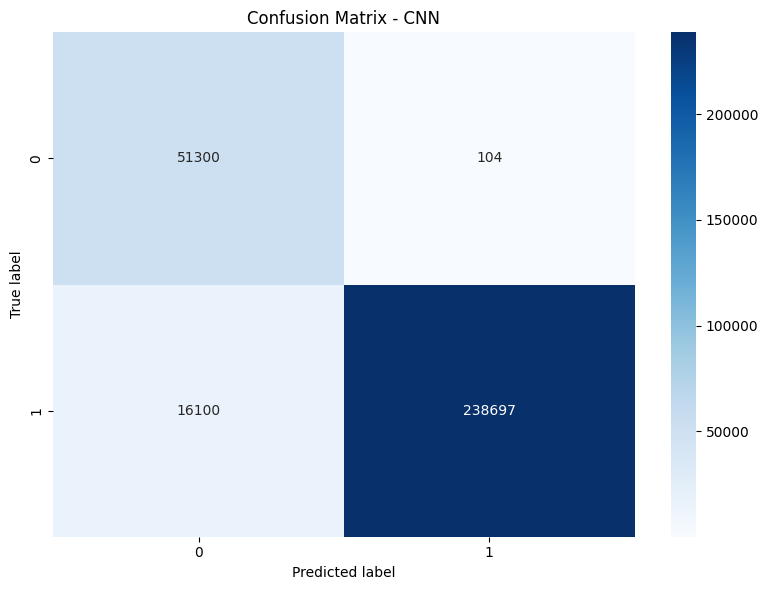


Classification Report (CNN):
              precision    recall  f1-score   support

           0       0.76      1.00      0.86     51404
           1       1.00      0.94      0.97    254797

    accuracy                           0.95    306201
   macro avg       0.88      0.97      0.92    306201
weighted avg       0.96      0.95      0.95    306201


Recall for each class (CNN):
  0: 0.9980
  1: 0.9368
9569/9569 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


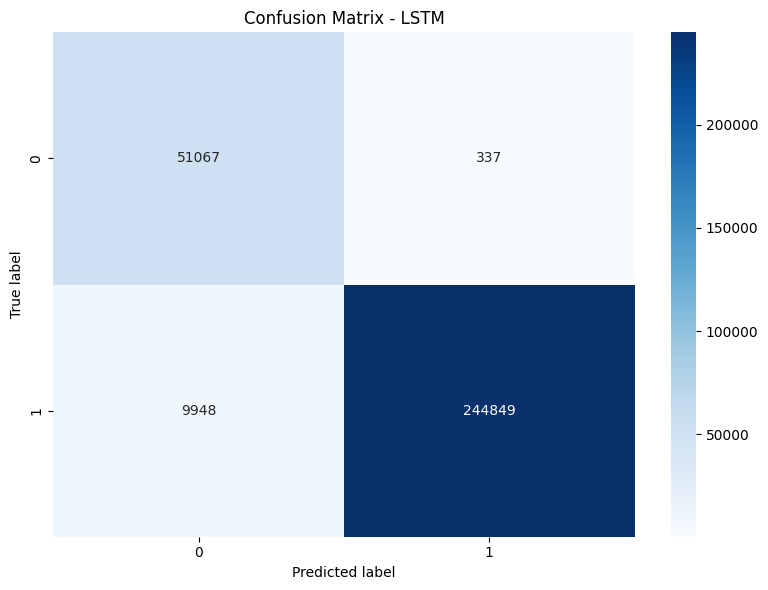


Classification Report (LSTM):
              precision    recall  f1-score   support

           0       0.84      0.99      0.91     51404
           1       1.00      0.96      0.98    254797

    accuracy                           0.97    306201
   macro avg       0.92      0.98      0.94    306201
weighted avg       0.97      0.97      0.97    306201


Recall for each class (LSTM):
  0: 0.9934
  1: 0.9610
9569/9569 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step


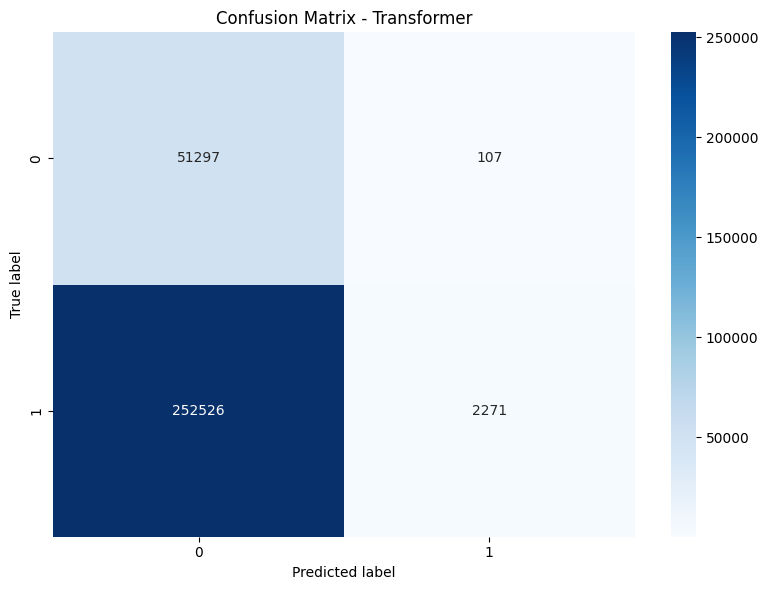


Classification Report (Transformer):
              precision    recall  f1-score   support

           0       0.17      1.00      0.29     51404
           1       0.96      0.01      0.02    254797

    accuracy                           0.17    306201
   macro avg       0.56      0.50      0.15    306201
weighted avg       0.82      0.17      0.06    306201


Recall for each class (Transformer):
  0: 0.9979
  1: 0.0089


In [ ]:
evaluate_model(cnn_model, X_test_model, y_test, y_train_bin_cat[:len(y_test)], "CNN")
evaluate_model(lstm_model, X_test_model, y_test, y_train_bin_cat[:len(y_test)], "LSTM")
evaluate_model(transformer_model, X_test_model, y_test, y_test_bin_cat, "Transformer")

In [1]:
from tabulate import tabulate

# Đánh giá lại các mô hình trên tập test
cnn_pred = np.argmax(cnn_model.predict(X_test_model), axis=1)
lstm_pred = np.argmax(lstm_model.predict(X_test_model), axis=1)
transformer_pred = np.argmax(transformer_model.predict(X_test_model), axis=1)

def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred)
    }

results = {
    'CNN': get_metrics(y_test, cnn_pred),
    'LSTM': get_metrics(y_test, lstm_pred),
    'Transformer': get_metrics(y_test, transformer_pred)
}

# In bảng so sánh
headers = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
table = []
for model, metrics in results.items():
    table.append([
        model,
        f"{metrics['accuracy']:.4f}",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['roc_auc']:.4f}"
    ])
print(tabulate(table, headers=headers, tablefmt='github'))

# Chọn mô hình tốt nhất theo F1-score
best_model_name = max(results, key=lambda m: results[m]['f1'])
print(f"\nMô hình tốt nhất: {best_model_name} (F1-score: {results[best_model_name]['f1']:.4f})")

# Lưu mô hình tốt nhất
if best_model_name == 'CNN':
    cnn_model.save('CNN_ddos_model.h5')
elif best_model_name == 'LSTM':
    lstm_model.save('LSTM_ddos_model.h5')
else:
    transformer_model.save('Transformer_ddos_model.h5')
print(f"Đã lưu mô hình: {best_model_name}_ddos_model.h5")

NameError: name 'np' is not defined

In [3]:
features_names = [
    'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max',
    'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
    'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
    'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Avg Packet Size',
    'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Act Data Packets', 'Fwd Seg Size Min',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std',
    'Idle Max', 'Idle Min'
]

In [4]:
# Collecting Training and Testing Dataset File Paths
df2019_train = []
dfps2019_test = []
labels = set()


for dirname, _, filenames in os.walk(r'E:\DACS\DACS\Data\CICDDoS2019'):

    for filename in filenames:
        if filename.endswith('-training.parquet'):
            dfp = os.path.join(dirname, filename)
            df2019_train.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)
        elif filename.endswith('-testing.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_test.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)

print("Các nhãn (label) tìm thấy trong CICDDos2019:")
for label in sorted(labels):
    print("-", label)

E:\DACS\DACS\Data\CICDDoS2019\DNS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Portmap-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\SNMP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\TFTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-training.parquet
Các nhãn (label) tìm thấy trong CICDDos2019:
- DNS
- LDAP
- MSSQL
- NTP
- NetBIOS
- Portmap
- SNMP
- Syn
- TFTP
- UDP

In [5]:
data_dir = r'E:\DACS\DACS\Data\CICDDoS2017'
labels = set()

df2017 = [] 
for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.parquet'):
            file_path = os.path.join(dirname, filename)
            df2017.append(file_path)
            label = filename.split('-')[0]
            labels.add(label)
            print(file_path)
print("Các nhãn (label) tìm thấy trong CICDDos2017:")
for label in sorted(labels):
    print("-", label)

E:\DACS\DACS\Data\CICDDoS2017\Benign-Monday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Botnet-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Bruteforce-Tuesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DDoS-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DoS-Wednesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Infiltration-Thursday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Portscan-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\WebAttacks-Thursday-no-metadata.parquet
Các nhãn (label) tìm thấy trong CICDDos2017:
- Benign
- Botnet
- Bruteforce
- DDoS
- DoS
- Infiltration
- Portscan
- WebAttacks


In [6]:
df_2017 = pd.concat([pd.read_parquet(dfp) for dfp in df2017], ignore_index=True)
df_2019 = pd.concat([pd.read_parquet(dfp) for dfp in df2019_train], ignore_index=True)

In [7]:
df = pd.concat([df_2017, df_2019], ignore_index=True)

In [8]:
# Lưu lại nhãn gốc làm cột AttackType (nếu trước đó nhãn gốc là Label)
df['AttackType'] = df['Label']

# Sau đó mới gộp nhãn Label về chỉ Benign/DDoS
def label_binary(row):
    return 'Benign' if row == 'Benign' else 'DDoS'
df['Label'] = df['Label'].apply(label_binary)

print("Label:", df['Label'].unique())
print("AttackType:", df['AttackType'].unique())


Label: ['Benign' 'DDoS']
AttackType: ['Benign' 'Bot' 'FTP-Patator' 'SSH-Patator' 'DDoS' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'Infiltration'
 'PortScan' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'NetBIOS' 'LDAP' 'MSSQL' 'Portmap' 'Syn'
 'UDP' 'UDPLag']


In [9]:
    # Chuẩn hóa AttackType về các nhóm nhỏ hơn cho phase 2
attack_group_map = {
        # DrDoS/Reflection
        'DrDoS_DNS': 'DrDoS',
        'DrDoS_SNMP': 'DrDoS',
        'DrDoS_NTP': 'DrDoS',
        'DrDoS_MSSQL': 'DrDoS',
        'DrDoS_SSDP': 'DrDoS',
        'DrDoS_UDP': 'DrDoS',
        'TFTP': 'TFTP',
        # DDoS truyền thống
        'UDP': 'UDP',
        'UDPLag': 'UDP',
        'Syn': 'Syn',
        'MSSQL': 'MSSQL',
        'LDAP': 'LDAP',
        # DoS - đơn lẻ
        'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS',
        'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS',
        'Heartbleed': 'Other',
        # Web
        'Web Attack � Brute Force': 'Web Attack',
        'Web Attack � XSS': 'Web Attack',
        'Web Attack � Sql Injection': 'Web Attack',
        # Brute Force & Infiltration
        'FTP-Patator': 'Brute Force',
        'SSH-Patator': 'Brute Force',
        'Infiltration': 'Other',
        'Bot': 'Other',
        # PortScan
        'PortScan': 'PortScan',
        # NetBIOS
        'NetBIOS': 'Other',
        # Other (các loại còn lại)
    }

def group_attack_type(x):
        if x == 'Benign':
            return 'Benign'
        return attack_group_map.get(x, 'Other')

df['AttackType'] = df['AttackType'].apply(group_attack_type)

print("Các nhóm attack sau khi chuẩn hóa:", df['AttackType'].unique())
print(df['AttackType'].value_counts())

Các nhóm attack sau khi chuẩn hóa: ['Benign' 'Other' 'Brute Force' 'DoS' 'PortScan' 'Web Attack' 'LDAP'
 'MSSQL' 'Syn' 'UDP']
AttackType
Benign         2023745
DoS             193745
Other           130827
Syn              48840
UDP              18145
Brute Force       9150
MSSQL             8523
Web Attack        2143
PortScan          1956
LDAP              1906
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

# Chỉ lấy DDoS
df_attack = df[df['Label'] == 'DDoS'].copy()
X_attack = df_attack[features_names].astype(np.float32).values
y_attack = df_attack['AttackType'].values

# Encode
# 2. Encode nhãn
label_encoder = LabelEncoder()
label_encoder.fit(y_attack)
y_attack_encoded = label_encoder.fit_transform(y_attack)
joblib.dump(label_encoder, "attack_label_encoder.pkl")
n_classes = len(label_encoder.classes_)
print("Các lớp attack:", label_encoder.classes_)

X_attack_train, X_attack_test, y_attack_train, y_attack_test = train_test_split(
    X_attack, y_attack_encoded,
    test_size=0.2, random_state=42, stratify=y_attack_encoded
)

y_attack_train_cat = to_categorical(y_attack_train, num_classes=n_classes)
y_attack_test_cat = to_categorical(y_attack_test, num_classes=n_classes)

scaler = MinMaxScaler()
scaler.fit(X_attack_train)
joblib.dump(scaler, 'scaler_attack.pkl')
X_attack_train_scaled = scaler.transform(X_attack_train)
X_attack_test_scaled = scaler.transform(X_attack_test)


Các lớp attack: ['Brute Force' 'DoS' 'LDAP' 'MSSQL' 'Other' 'PortScan' 'Syn' 'UDP'
 'Web Attack']


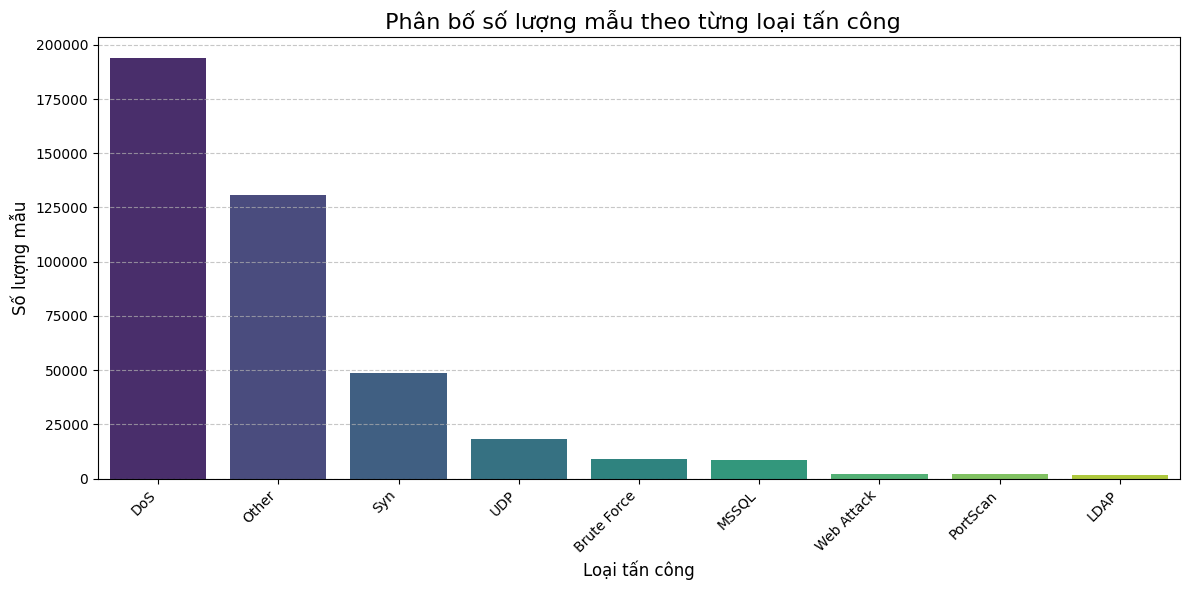

In [11]:
# Đếm số lượng mỗi lớp tấn công
attack_counts = pd.Series(y_attack).value_counts().sort_values(ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(x=attack_counts.index, y=attack_counts.values, palette="viridis")

plt.title(" Phân bố số lượng mẫu theo từng loại tấn công", fontsize=16)
plt.xlabel("Loại tấn công", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

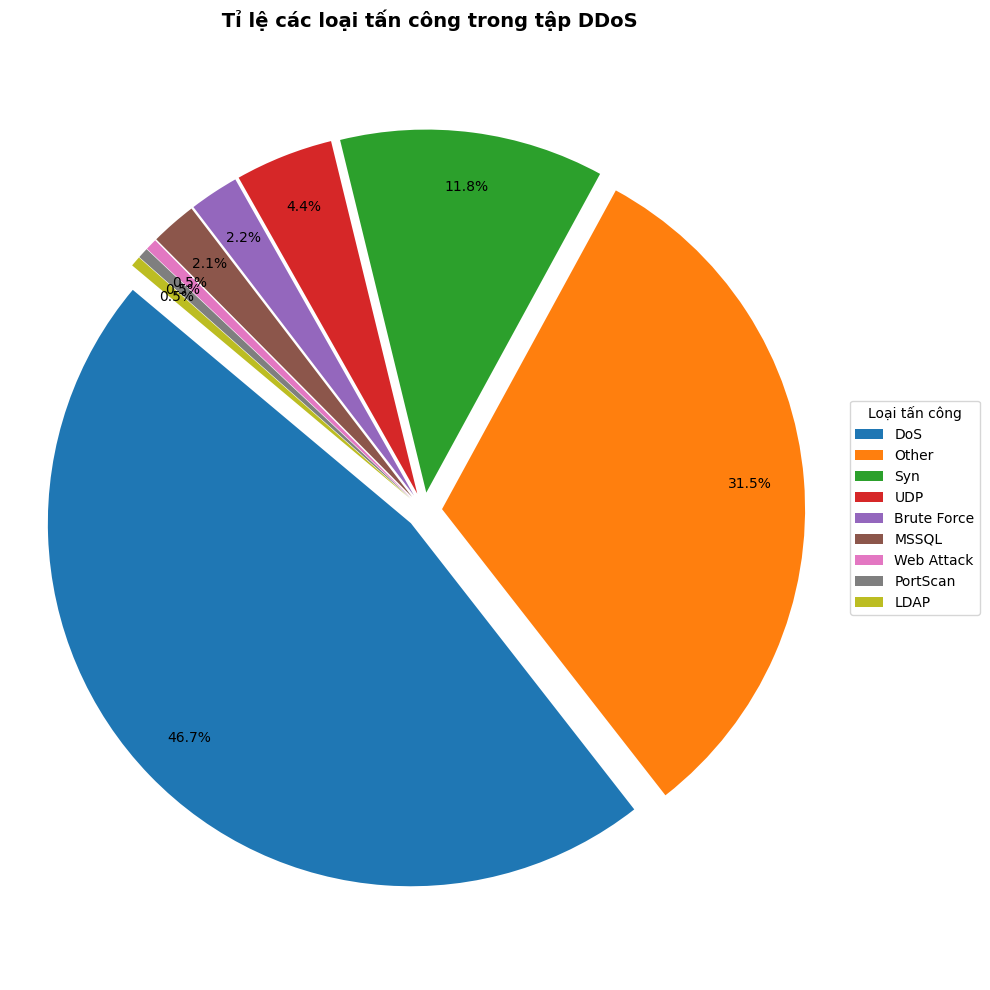

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Phân bố attack
attack_distribution = pd.Series(y_attack).value_counts()

# Các tham số tách từng phần ra một chút để tránh đè
explode = [0.05] * len(attack_distribution)

# Vẽ Pie Chart
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    attack_distribution.values,
    labels=None,  # Không chèn nhãn vào trong pie
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.85,       # Đẩy % ra xa hơn
    labeldistance=1.1,      # Đẩy nhãn (nếu dùng) ra ngoài
    textprops={'fontsize': 10}
)

# Chú thích ngoài
ax.legend(
    wedges,
    attack_distribution.index,
    title="Loại tấn công",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.title(" Tỉ lệ các loại tấn công trong tập DDoS", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [20]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_attack_train_res, y_attack_train_res = sm.fit_resample(X_attack_train, y_attack_train)

# One-hot encoding nhãn cho train
y_attack_train_cat = to_categorical(y_attack_train_res)

print("Số lượng mẫu train sau khi oversample:", len(y_attack_train_res))

Số lượng mẫu train sau khi oversample: 1394964


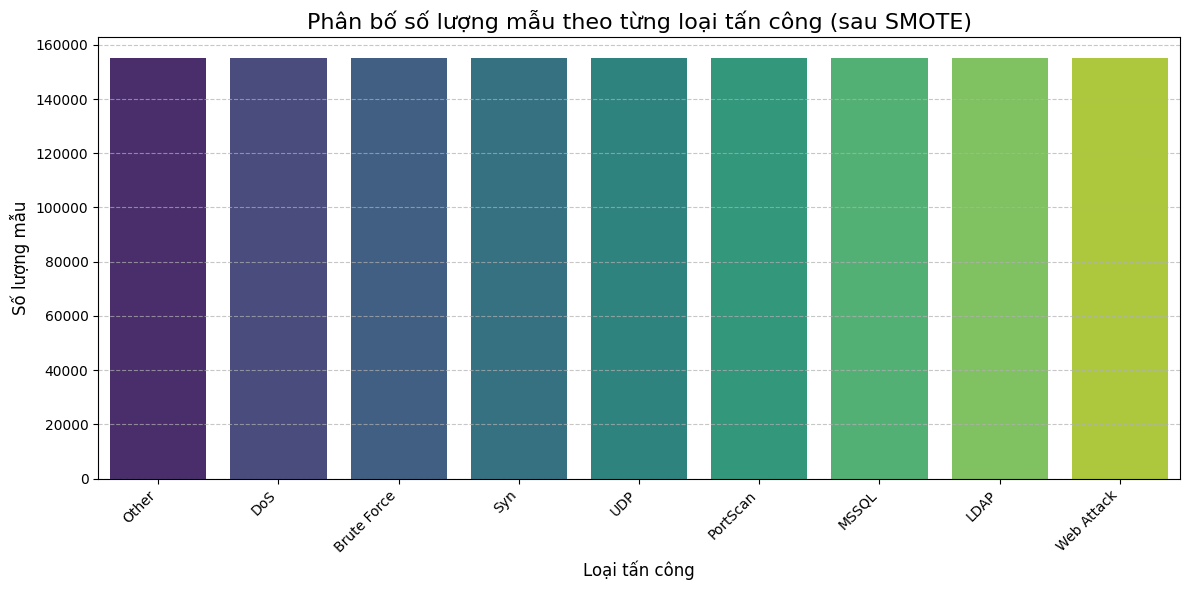

In [14]:

try:
    attack_labels_after = label_encoder.inverse_transform(y_attack_train_res)
except:
    attack_labels_after = y_attack_train_res

attack_counts_after = pd.Series(attack_labels_after).value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=attack_counts_after.index, y=attack_counts_after.values, palette="viridis")

plt.title("Phân bố số lượng mẫu theo từng loại tấn công (sau SMOTE)", fontsize=16)
plt.xlabel("Loại tấn công", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
X_attack_train_scaled_cnn = X_attack_train_scaled.reshape(-1, len(features_names), 1)
X_attack_test_scaled_cnn = X_attack_test_scaled.reshape(-1, len(features_names), 1)

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Bidirectional, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Custom Attention Layer cho 1D sequence
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

def create_cnn_bilstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(128, kernel_size=5, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    attn = AttentionLayer()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(attn)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [19]:
# Huấn luyện trên tập train đã SMOTE, chuẩn hóa và reshape
model = create_cnn_bilstm_attention(X_attack_train_scaled_cnn.shape[1:], n_classes)

history = model.fit(
    X_attack_train_scaled_cnn, y_attack_train_cat,
    epochs=30,
    batch_size=16,
    validation_data=(X_attack_test_scaled_cnn, y_attack_test_cat),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# Lưu model
model.save('attack_classifier_cnn_bilstm_attention.h5')


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 332188
'y' sizes: 1394964


In [ ]:
y_attack_test_labels = label_encoder.inverse_transform(y_attack_test)

2596/2596 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step


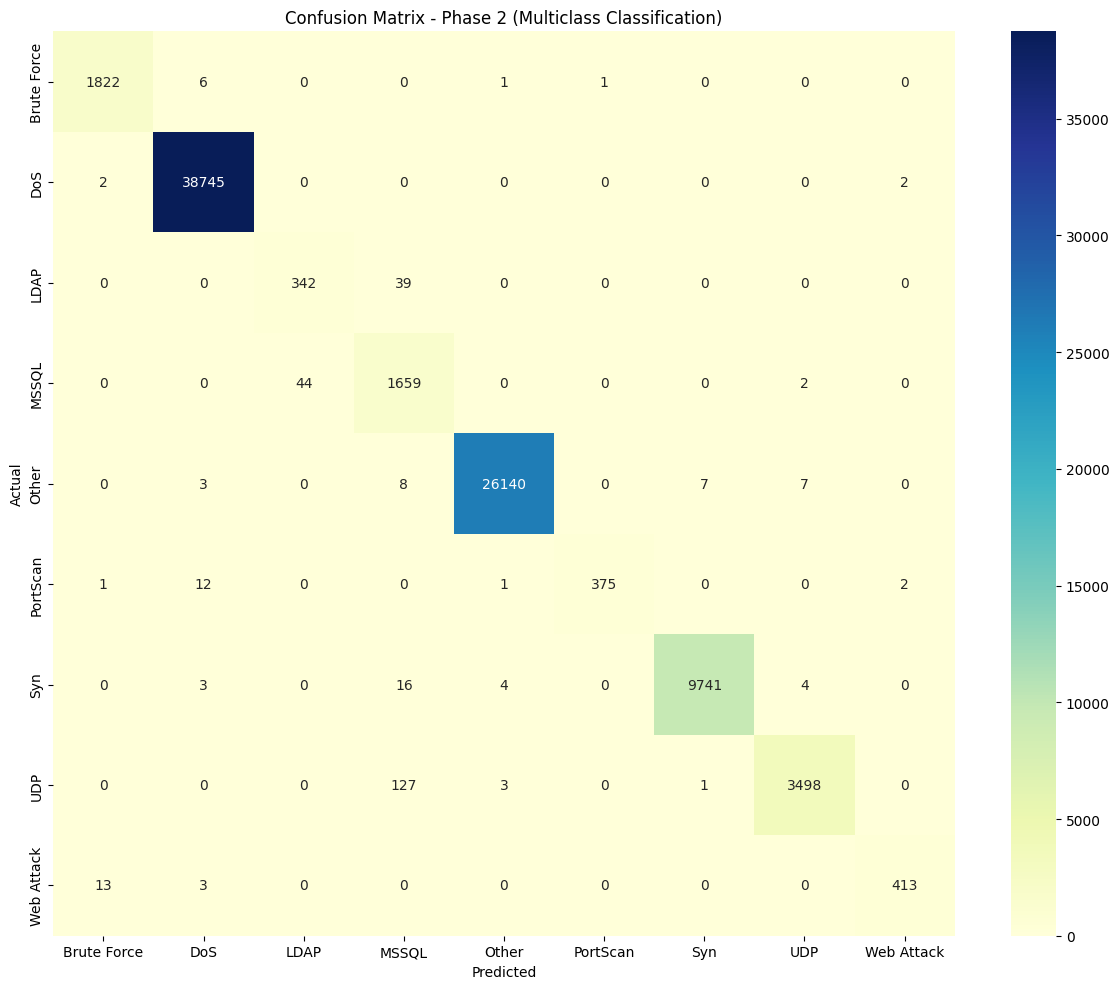

              precision    recall  f1-score   support

 Brute Force       0.99      1.00      0.99      1830
         DoS       1.00      1.00      1.00     38749
        LDAP       0.89      0.90      0.89       381
       MSSQL       0.90      0.97      0.93      1705
       Other       1.00      1.00      1.00     26165
    PortScan       1.00      0.96      0.98       391
         Syn       1.00      1.00      1.00      9768
         UDP       1.00      0.96      0.98      3629
  Web Attack       0.99      0.96      0.98       429

    accuracy                           1.00     83047
   macro avg       0.97      0.97      0.97     83047
weighted avg       1.00      1.00      1.00     83047



In [ ]:
# Dự đoán lại trên toàn bộ attack samples
y_attack_test_pred_prob = model.predict(X_attack_test_scaled_cnn)
y_attack_test_pred = np.argmax(y_attack_test_pred_prob, axis=1)

labels_multi = label_encoder.classes_
cm_multi = confusion_matrix(y_attack_test, y_attack_test_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=labels_multi, yticklabels=labels_multi)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Phase 2 (Multiclass Classification)")
plt.tight_layout()
plt.show()

print(classification_report(y_attack_test, y_attack_test_pred, target_names=labels_multi))